In [ ]:
# Install/import the libraries we need

import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


## 1. Dataset Selection



In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


DATASET_ROOT = "/content/drive/MyDrive/brain_tumor_mri_dataset"

SOURCE_TRAIN_DIR = os.path.join(DATASET_ROOT, "Training")

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

SAMPLES_PER_CLASS = 100
TRAIN_PER_CLASS = 70
VAL_PER_CLASS = 15
TEST_PER_CLASS = 15

print("Dataset path:", DATASET_ROOT)
print("Training path:", SOURCE_TRAIN_DIR)

Dataset path: /content/drive/MyDrive/brain_tumor_mri_dataset
Training path: /content/drive/MyDrive/brain_tumor_mri_dataset/Training


In [ ]:
# Check whether the folders exist

print("Training folder exists:", os.path.exists(SOURCE_TRAIN_DIR))

for cls in CLASSES:
    class_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    print(f"{cls:12s} -> {len(os.listdir(class_path)) if os.path.exists(class_path) else 'FOLDER NOT FOUND'} images")

Training folder exists: True
glioma       -> 1400 images
meningioma   -> 1400 images
notumor      -> 1400 images
pituitary    -> 1400 images


## 2. Dataset Preparation



In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

WORKING_DIR = "/content/brain_tumor_100"

# Remove an old copy if it exists
if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)

for split in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(WORKING_DIR, split, cls), exist_ok=True)

# Supported image extensions
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for cls in CLASSES:
    source_class_dir = os.path.join(SOURCE_TRAIN_DIR, cls)

    image_files = [
        f for f in os.listdir(source_class_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]

    random.shuffle(image_files)

    if len(image_files) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"{cls} has only {len(image_files)} images, "
            f"but {SAMPLES_PER_CLASS} are required."
        )

    selected = image_files[:SAMPLES_PER_CLASS]

    train_files = selected[:TRAIN_PER_CLASS]
    val_files = selected[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VAL_PER_CLASS]
    test_files = selected[TRAIN_PER_CLASS + VAL_PER_CLASS:]

    splits = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split, files in splits.items():
        for filename in files:
            src = os.path.join(source_class_dir, filename)
            dst = os.path.join(WORKING_DIR, split, cls, filename)
            shutil.copy2(src, dst)

print("Dataset preparation completed!")

Dataset preparation completed!


In [ ]:
# Verify exactly how many images we have

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    total = 0

    for cls in CLASSES:
        folder = os.path.join(WORKING_DIR, split, cls)
        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(IMAGE_EXTENSIONS)
        ])
        total += count
        print(f"{cls:12s}: {count}")

    print("Total:", total)


TRAIN
glioma      : 70
meningioma  : 70
notumor     : 70
pituitary   : 70
Total: 280

VAL
glioma      : 15
meningioma  : 15
notumor     : 15
pituitary   : 15
Total: 60

TEST
glioma      : 15
meningioma  : 15
notumor     : 15
pituitary   : 15
Total: 60


## 3. Data Preprocessing

A CNN expects a consistent tensor shape.

We will:
1. Resize every image to `128 × 128`
2. Convert images to tensors
3. Normalize pixel values

For the validation and test sets, we do **not** use random transformations.

In [ ]:
IMAGE_SIZE = 128
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

## 4. Data Augmentation

Because the training set is very small, augmentation can create slightly different versions of training images.

Here we use:
- small rotation
- horizontal flip
- small translation

**Important:** augmentation is applied only to the training set.

This helps the model see more variation without changing the original validation/test images.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [ ]:
# Create datasets

train_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(WORKING_DIR, "test"),
    transform=eval_transform
)

print("Class names:", train_dataset.classes)
print("Class-to-index:", train_dataset.class_to_idx)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class-to-index: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train: 280
Validation: 60
Test: 60


In [ ]:
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders ready!")

DataLoaders ready!


# 5. CNN Model Architecture



In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            # 3 x 128 x 128
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16 x 64 x 64
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 32 x 32 x 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            # 64 x 16 x 16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(num_classes=len(CLASSES)).to(device)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:
# Count trainable parameters

total_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Trainable parameters:", total_params)

Trainable parameters: 2121380


## 6. Model Training

We use:
- Loss: `CrossEntropyLoss`
- Optimizer: Adam
- Learning rate: `0.001`
- Epochs: 15

During each epoch we calculate both training and validation loss/accuracy.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 15

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Training loop

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [01/15] | Train Loss: 1.3678 | Train Acc: 0.3071 | Val Loss: 1.2966 | Val Acc: 0.3833
Epoch [02/15] | Train Loss: 1.1533 | Train Acc: 0.4500 | Val Loss: 1.0453 | Val Acc: 0.5333
Epoch [03/15] | Train Loss: 1.0360 | Train Acc: 0.5750 | Val Loss: 0.9658 | Val Acc: 0.6667
Epoch [04/15] | Train Loss: 0.8837 | Train Acc: 0.5964 | Val Loss: 0.7966 | Val Acc: 0.7167
Epoch [05/15] | Train Loss: 0.8636 | Train Acc: 0.6571 | Val Loss: 0.7698 | Val Acc: 0.7167
Epoch [06/15] | Train Loss: 0.8160 | Train Acc: 0.6821 | Val Loss: 0.6497 | Val Acc: 0.7500
Epoch [07/15] | Train Loss: 0.7061 | Train Acc: 0.7214 | Val Loss: 0.5900 | Val Acc: 0.7667
Epoch [08/15] | Train Loss: 0.6621 | Train Acc: 0.7143 | Val Loss: 0.5753 | Val Acc: 0.7500
Epoch [09/15] | Train Loss: 0.6446 | Train Acc: 0.7393 | Val Loss: 0.5360 | Val Acc: 0.7667
Epoch [10/15] | Train Loss: 0.5518 | Train Acc: 0.7643 | Val Loss: 0.5279 | Val Acc: 0.7333
Epoch [11/15] | Train Loss: 0.5743 | Train Acc: 0.7571 | Val Loss: 0.6007 | Val 

## Training Curves

These graphs help us understand whether the model is learning and whether there may be overfitting.

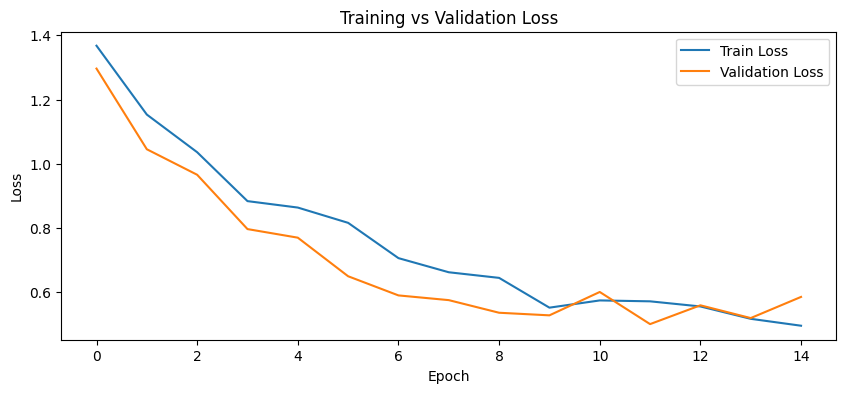

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

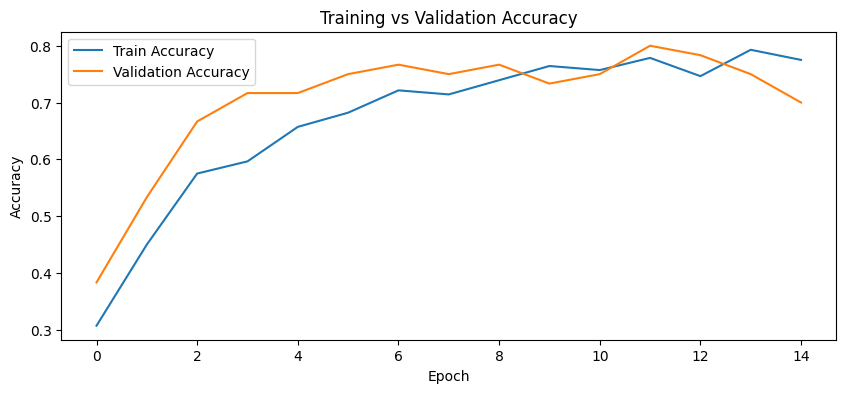

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# 7. Model Evaluation

Now we evaluate the model on the **unseen test set**.

We will calculate:
- Test accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_accuracy = (all_predictions == all_labels).mean()

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7833


In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9091    0.6667    0.7692        15
  meningioma     0.6471    0.7333    0.6875        15
     notumor     0.9167    0.7333    0.8148        15
   pituitary     0.7500    1.0000    0.8571        15

    accuracy                         0.7833        60
   macro avg     0.8057    0.7833    0.7822        60
weighted avg     0.8057    0.7833    0.7822        60



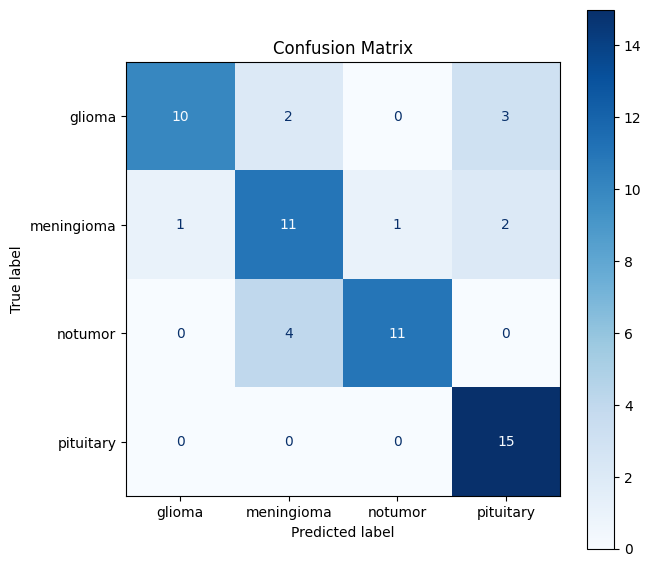

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# 8. Prediction & Inference

Now we will give the model **one image** and ask:

> Which class does the model predict?

We also show the confidence score from the softmax probabilities.

Remember: confidence is the model's probability output, **not medical certainty**.

In [ ]:
def predict_image(model, image_path, class_names, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # Same preprocessing used for validation/test
    input_tensor = eval_transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item()

    return image, predicted_class, confidence, probabilities.cpu().numpy()[0]

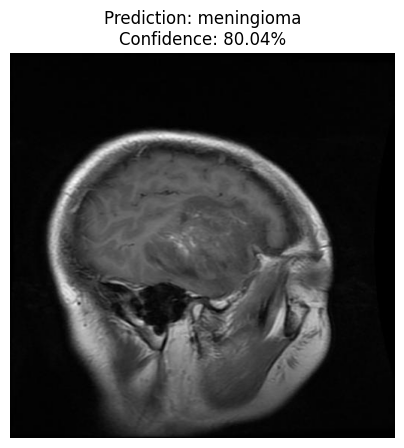

Image: /content/brain_tumor_100/test/glioma/Tr-gl_1095.jpg
Predicted class: meningioma
Confidence: 80.04%

Class probabilities:
glioma      : 19.94%
meningioma  : 80.04%
notumor     : 0.01%
pituitary   : 0.01%


In [ ]:
# Pick one test image automatically

sample_path = test_dataset.samples[0][0]

image, predicted_class, confidence, probabilities = predict_image(
    model,
    sample_path,
    test_dataset.classes,
    device
)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)
plt.axis("off")
plt.show()

print("Image:", sample_path)
print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

print("\nClass probabilities:")
for class_name, prob in zip(test_dataset.classes, probabilities):
    print(f"{class_name:12s}: {prob:.2%}")